In [63]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load dataset
df = pd.read_csv('/Users/anupamverma/Downloads/netflix_titles.csv')

# First look at data
print(df.shape)        # rows and columns
print(df.head())       # first 5 rows
print(df.info())       # data types
print(df.columns)      # column names

(8807, 12)
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2

In [64]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [65]:
# Fix missing values

# Director - fill with Unknown
df['director']=df['director'].fillna('Unknown')

# Cast - fill with Unknown
df['cast']=df['cast'].fillna('Unknown')

# Country - fill with Unknown
df['country']=df['country'].fillna('Unknown')

# Date added - drop those rows (only 10 rows)
df.dropna(subset=['date_added'], inplace=True)

# Rating - fill with most common rating
if not df['rating'].mode().empty:
   most_common_rating = df['rating'].mode()[0]
   df['rating']=df['rating'].fillna(most_common_rating)
else:
   df['rating']=df['rating'].fillna('unknown')


# Duration - drop null rows
df.dropna(subset=['duration'], inplace=True)

# Verify - should show 0 or very less
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [66]:
# Converting date to date formate
df['date_added']=df['date_added'].str.strip()
df['date_added']=pd.to_datetime(df['date_added'])
print(df['date_added'].head())

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[us]


In [67]:
# Finding Duplicate Values
print("Duplicates:" ,df.duplicated().sum())

Duplicates: 0


In [68]:
# Split Columns(Gener&Country)
df['genre_list']=df['listed_in'].str.split(',')
df['genre_list']=df['genre_list'].apply(
    lambda x:[gen.strip() for gen in x])
df['country_list']=df['country'].str.split(',')
df['country_list']=df['country_list'].apply(
    lambda x:[cun.strip() for cun in x])
df['primary_country']=df['country'].str.split(',').str[0].str.strip()
df['primary_genre']=df['listed_in'].str.split(',').str[0].str.strip()
print(df[['listed_in','genre_list','primary_genre']].head())
print(df[['country','country_list','primary_country']].head())

                                           listed_in  \
0                                      Documentaries   
1    International TV Shows, TV Dramas, TV Mysteries   
2  Crime TV Shows, International TV Shows, TV Act...   
3                             Docuseries, Reality TV   
4  International TV Shows, Romantic TV Shows, TV ...   

                                          genre_list           primary_genre  
0                                    [Documentaries]           Documentaries  
1  [International TV Shows, TV Dramas, TV Mysteries]  International TV Shows  
2  [Crime TV Shows, International TV Shows, TV Ac...          Crime TV Shows  
3                           [Docuseries, Reality TV]              Docuseries  
4  [International TV Shows, Romantic TV Shows, TV...  International TV Shows  
         country     country_list primary_country
0  United States  [United States]   United States
1   South Africa   [South Africa]    South Africa
2        Unknown        [Unknown]      

In [69]:
df.to_csv('netflix_cleaned.csv', index=False)
print("Clean dataset Shape:",df.shape)
print(df.head())

Clean dataset Shape: (8794, 16)
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water          Unknown   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans          Unknown   
4      s5  TV Show           Kota Factory          Unknown   

                                                cast        country  \
0                                            Unknown  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...        Unknown   
3                                            Unknown        Unknown   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

  date_added  release_year rating   duration  \
0 2021-09-25          2020  PG-13     90 min   
1 2021-09-24          2021  TV-MA  2 Seasons   
2 2021-09-24          20

In [70]:
# Count Type of Content
type_count=df['type'].value_counts()
type_percent=df['type'].value_counts(normalize=True)*100
print(type_count)
print(type_percent.round(2))

type
Movie      6128
TV Show    2666
Name: count, dtype: int64
type
Movie      69.68
TV Show    30.32
Name: proportion, dtype: float64


In [71]:
# Top 10 Genre
genre=df.explode('genre_list')    #Transform each element of a list column into seperate row
top_genre=genre['genre_list'].value_counts().head(10)
print("Top 10 Genre")
print(top_genre)

Top 10 Genre
genre_list
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [72]:
# Content Added Per Year Trend
yearly_content=df.groupby([df['date_added'].dt.year,'type']).size().reset_index()  
# reset_index()->convert resulting groupby series into structured dataframe(index levels into regular columns
yearly_content.columns=['year','type','count']   #Setting Colums Name
print("Yearly Content")
print(yearly_content)

# Monthly trend
monthly_content=df.groupby([df['date_added'].dt.month,'type']).size().reset_index()
monthly_content.columns=['month','type','count']
print("Monthly Content") 
print(monthly_content)

# Year-Monthly trend
Year_Monthly_content=df.groupby([sorted(df['date_added'].dt.strftime('%Y-%m')),'type']).size().reset_index()
Year_Monthly_content.columns=['Year-Month','type','count']
print("Year-Monthly Content") 
print(Year_Monthly_content)

Yearly Content
    year     type  count
0   2008    Movie      1
1   2008  TV Show      1
2   2009    Movie      2
3   2010    Movie      1
4   2011    Movie     13
5   2012    Movie      3
6   2013    Movie      6
7   2013  TV Show      5
8   2014    Movie     19
9   2014  TV Show      5
10  2015    Movie     56
11  2015  TV Show     26
12  2016    Movie    251
13  2016  TV Show    176
14  2017    Movie    838
15  2017  TV Show    349
16  2018    Movie   1237
17  2018  TV Show    412
18  2019    Movie   1424
19  2019  TV Show    592
20  2020    Movie   1284
21  2020  TV Show    595
22  2021    Movie    993
23  2021  TV Show    505
Monthly Content
    month     type  count
0       1    Movie    546
1       1  TV Show    192
2       2    Movie    382
3       2  TV Show    181
4       3    Movie    529
5       3  TV Show    213
6       4    Movie    549
7       4  TV Show    214
8       5    Movie    439
9       5  TV Show    193
10      6    Movie    492
11      6  TV Show    236
12    

In [73]:
# Top Countries Producing Content
producing_country=df.explode('country_list')
producing_country=producing_country[producing_country['country_list']!= 'Unknown']
top_countries=producing_country['country_list'].value_counts().head(10)
print("Top 10 Countries")
print(top_countries)

Top 10 Countries
country_list
United States     3681
India             1046
United Kingdom     805
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


In [74]:
# Most Common Ratings
rating_counts=df['rating'].value_counts()
print("Ratings Distribution")
print(rating_counts)

# Common Ratings by Types
rating_by_type=df.groupby(['type','rating']).size().reset_index()
rating_by_type.columns=['type','rating','count']
print(rating_by_type)

Ratings Distribution
rating
TV-MA       3209
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64
       type    rating  count
0     Movie         G     41
1     Movie     NC-17      3
2     Movie        NR     75
3     Movie        PG    287
4     Movie     PG-13    490
5     Movie         R    797
6     Movie     TV-14   1427
7     Movie      TV-G    126
8     Movie     TV-MA   2064
9     Movie     TV-PG    540
10    Movie      TV-Y    131
11    Movie     TV-Y7    139
12    Movie  TV-Y7-FV      5
13    Movie        UR      3
14  TV Show        NR      4
15  TV Show         R      2
16  TV Show     TV-14    730
17  TV Show      TV-G     94
18  TV Show     TV-MA   1145
19  TV Show     TV-PG    321
20  TV Show      TV-Y    175
21  TV Show     TV-Y7    194
22  TV Show  TV-Y7-FV      1


In [75]:
# Set style for all charts
plt.style.use('dark_background')
sns.set_palette("Set2")
# Standard figure size
plt.rcParams['figure.figsize']=(12,6)
plt.rcParams['font.size']=12

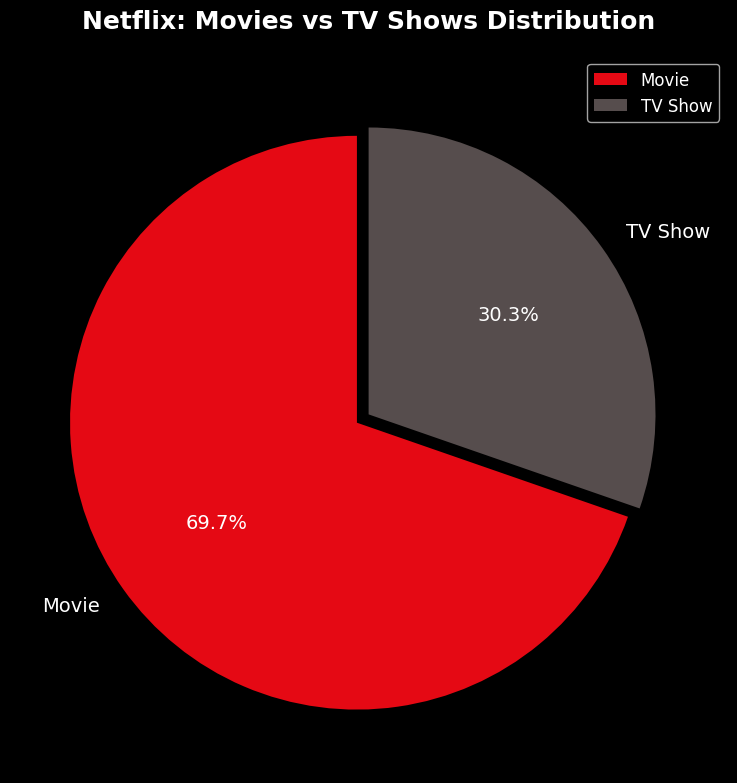

In [76]:
# Movies v/s TV Shows (Pie Chart)
type_counts=df['type'].value_counts()
fig,ax=plt.subplots(figsize=(8,8))
colors=['#E50914','#564d4d']
explode=(0.05,0)
ax.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=90,
    textprops={'fontsize':14}
)
ax.set_title('Netflix: Movies vs TV Shows Distribution',fontsize=18, 
             fontweight='bold', pad=20)
plt.tight_layout()
ax.legend(fontsize=12)
plt.savefig('movies_vs_tvshows.png', dpi=150, bbox_inches='tight')
plt.show()

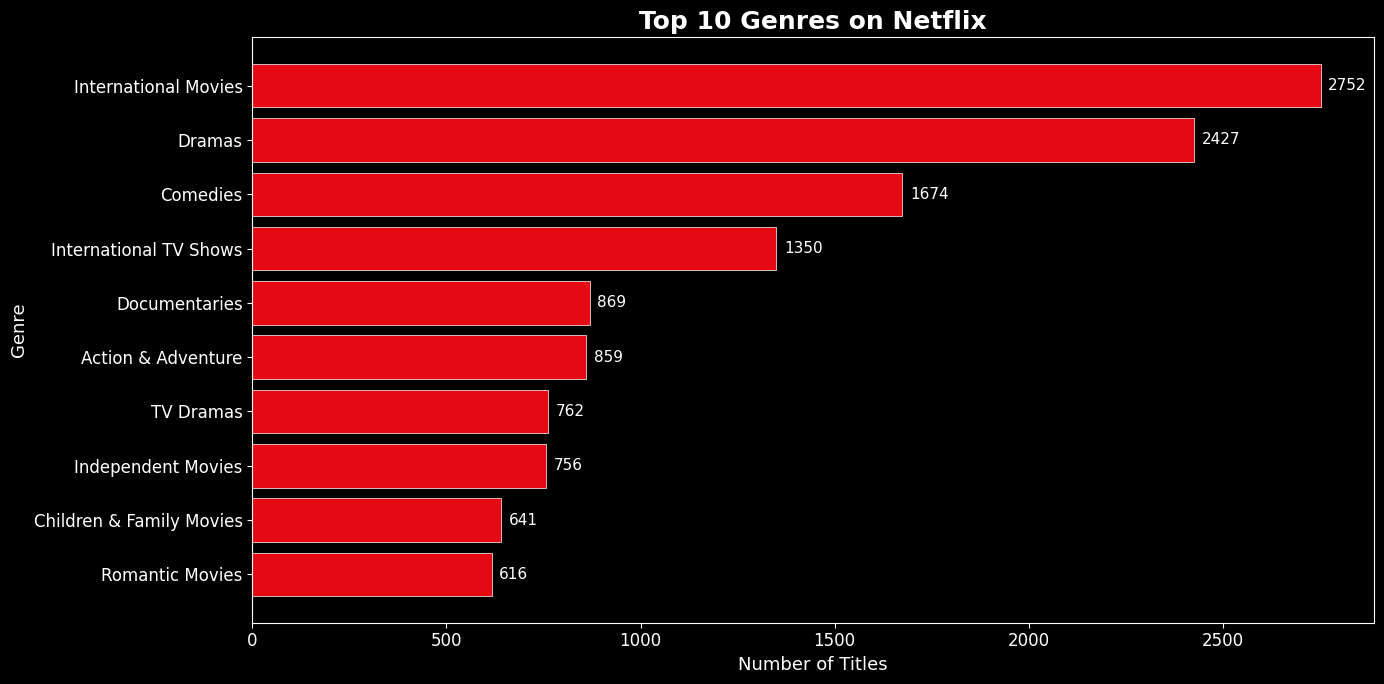

In [77]:
# Top 10 Genres on Netflix (Bar Chart)
genre_df=df.explode('genre_list')
top_genres=genre_df['genre_list'].value_counts().head(10)
fig,ax =plt.subplots(figsize=(14,7))
bars=ax.barh(
    top_genres.index[::-1],
    top_genres.values[::-1],
    color='#E50914',
    edgecolor='white',
    linewidth=0.5
)
for bar,value in zip(bars,top_genres.values[::-1]):
   ax.text(
       bar.get_width()+20,
       bar.get_y()+bar.get_height()/2,
       str(value),
       va='center',
       fontsize=11
   )
ax.set_title('Top 10 Genres on Netflix',fontsize=18, fontweight='bold')
ax.set_xlabel('Number of Titles',fontsize=13)
ax.set_ylabel('Genre',fontsize=13)
plt.tight_layout()
plt.savefig('top_genres.png',dpi=150,bbox_inches='tight')
plt.show()    

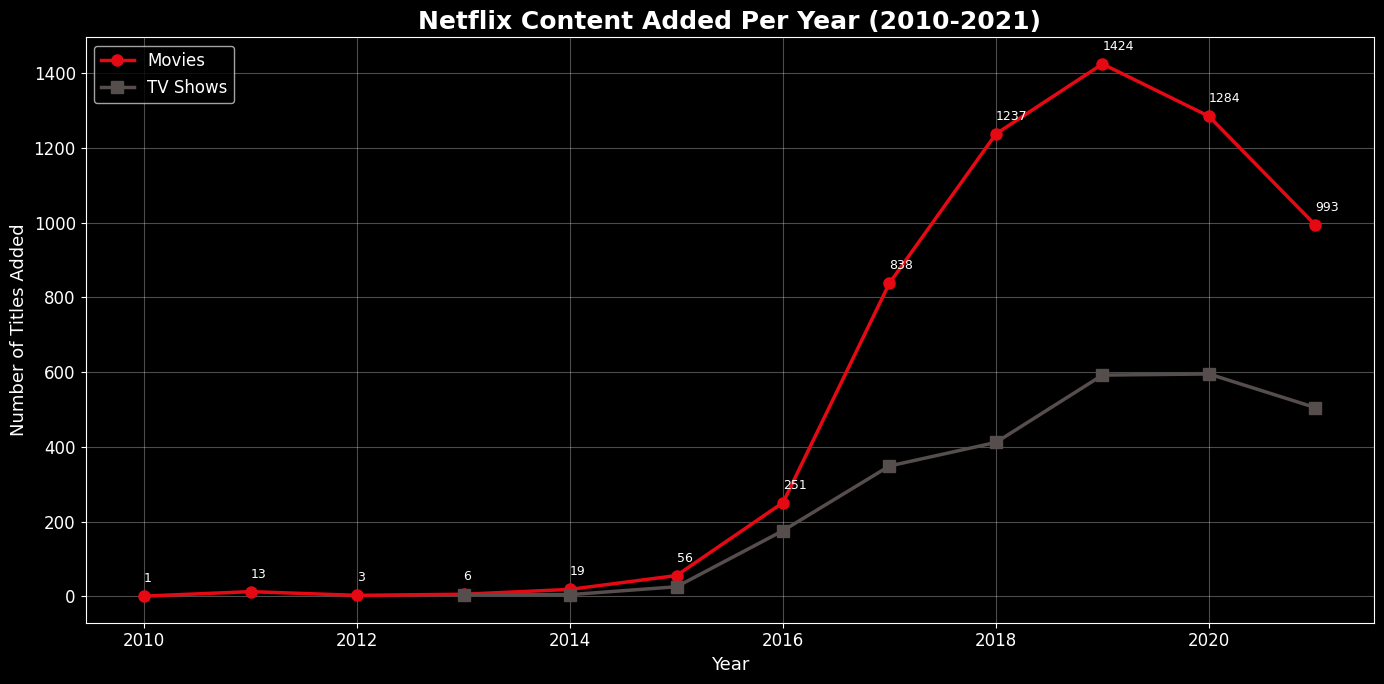

In [78]:
# Content Added Per Year (Line Chart)
yearly_content=df.groupby([df['date_added'].dt.year,'type']).size().reset_index()
yearly_content.columns=['year','type','count']
yearly_content=yearly_content[yearly_content['year']>=2010]
movies=yearly_content[yearly_content['type']=='Movie']
shows=yearly_content[yearly_content['type']=='TV Show']
# print(yearly_content)
# print(movies)
# print(shows)

fig,ax=plt.subplots(figsize=(14,7))
ax.plot(movies['year'],movies['count'],marker='o',linewidth=2.5,
        color='#E50914',label='Movies',markersize=8)
ax.plot(shows['year'],shows['count'],marker='s',linewidth=2.5,
        color='#564d4d',label='TV Shows',markersize=8)
for _,row in movies.iterrows():
    ax.annotate(str(int(row['count'])), (row ['year'],row['count']),
    textcoords="offset points",
    xytext=(0,10),fontsize=9)

ax.set_title('Netflix Content Added Per Year (2010-2021)',
             fontsize=18,fontweight='bold')
ax.set_xlabel('Year',fontsize=13)
ax.set_ylabel('Number of Titles Added',fontsize=13)
ax.legend(fontsize=12)
ax.grid(True,alpha=0.3)

plt.tight_layout()
plt.savefig('content_per_year.png',dpi=150, bbox_inches='tight')
plt.show()

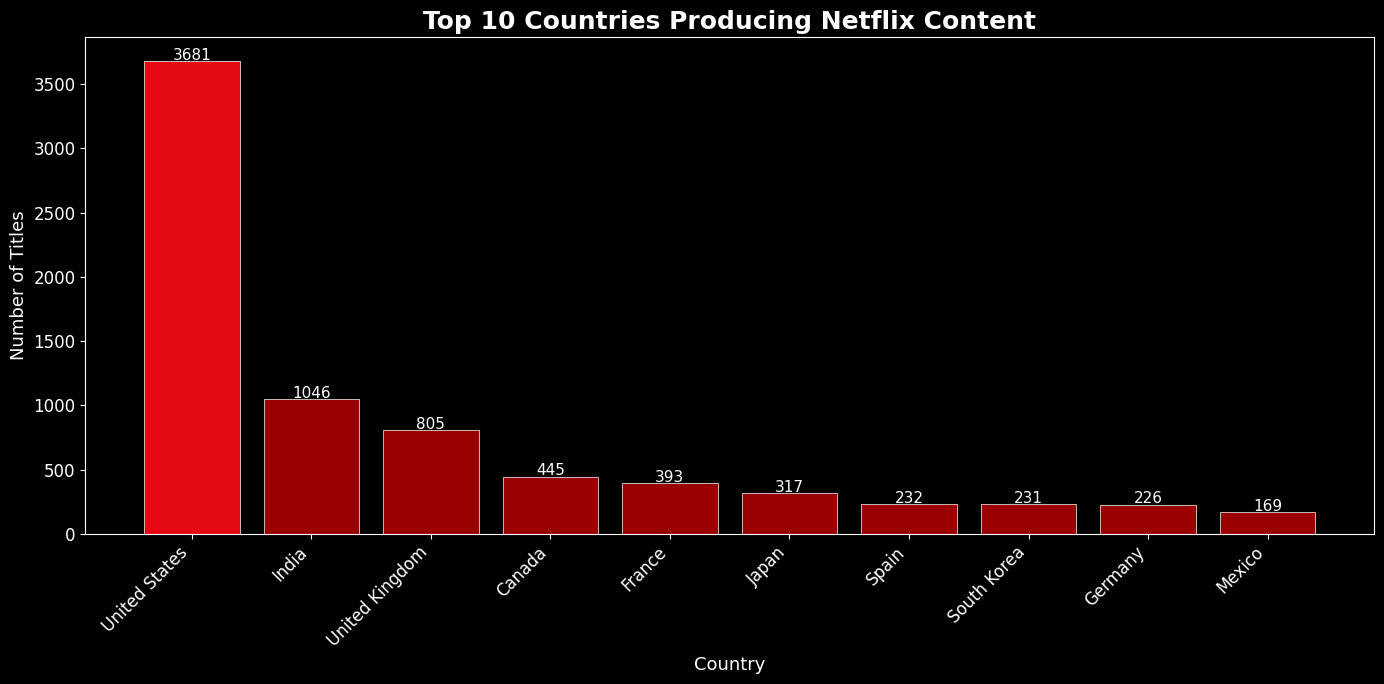

In [79]:
# Top Countries (Bar Chart)
country_df=df.explode('country_list')
country_df=country_df[country_df['country_list'] !='Unknown']
top_country=country_df['country_list'].value_counts().head(10)
# print(top_country)
fig,ax=plt.subplots(figsize=(14,7))
colors=['#E50914' if i==0 else '#9b0000'
        for i in range(len(top_country))]
bars=ax.bar(
    top_country.index,
    top_country.values,
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

for bar in bars:
    ax.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+10,
        str(bar.get_height()),
        ha='center',fontsize=11
    )
ax.set_title('Top 10 Countries Producing Netflix Content',
              fontsize=18,fontweight='bold')
ax.set_xlabel('Country', fontsize=13)
ax.set_ylabel('Number of Titles', fontsize=13)
plt.xticks(rotation=45,ha='right')

plt.tight_layout()
plt.savefig('top_countries.png' , dpi=150, bbox_inches='tight')
plt.show()

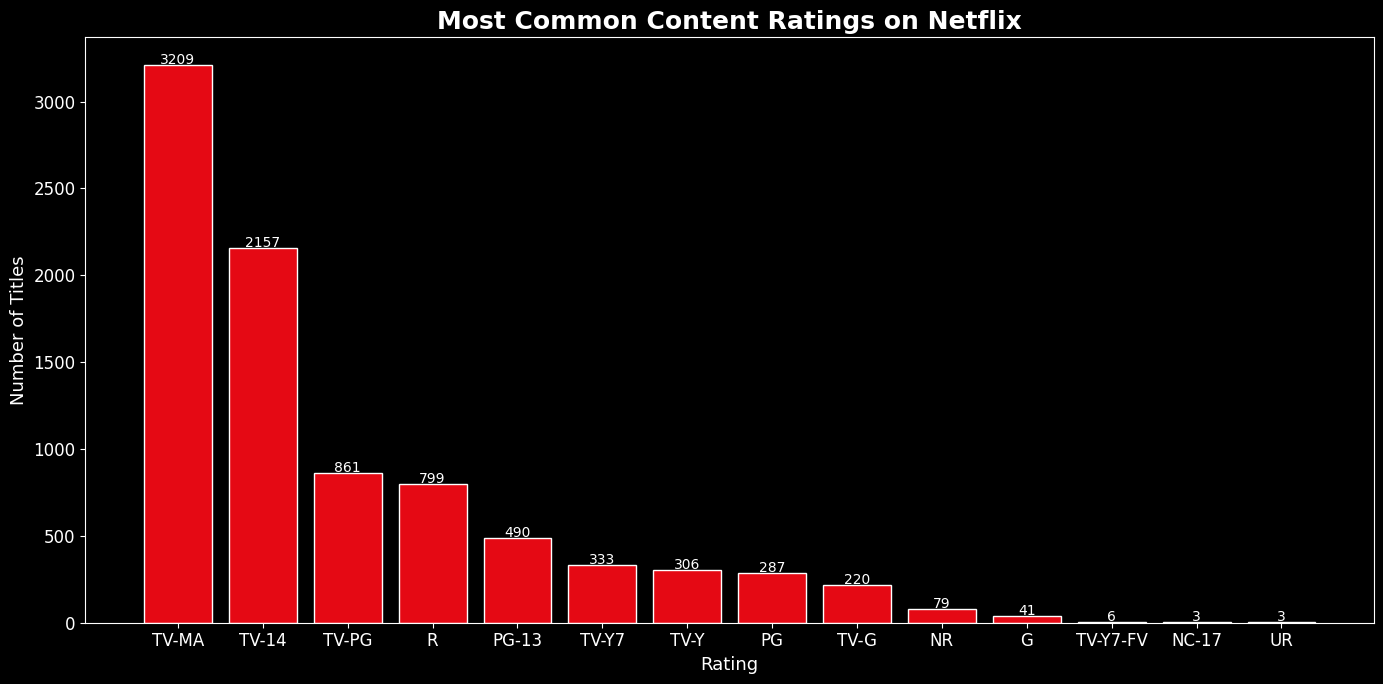

In [80]:
# Rating Distribution(Bar Chart)
rating_counts=df['rating'].value_counts()

fig, ax =plt.subplots(figsize=(14,7))

bars=ax.bar(
    rating_counts.index,
    rating_counts.values,
    color='#E50914',
    edgecolor='white'
)

for bar in bars:
    ax.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+5,
        str(bar.get_height()),
        ha='center', fontsize=10
    )
ax.set_title('Most Common Content Ratings on Netflix',
             fontsize=18, fontweight='bold')
ax.set_xlabel('Rating',fontsize=13)
ax.set_ylabel('Number of Titles',fontsize=13)

plt.tight_layout()
plt.savefig('rating.png',dpi=150,bbox_inches='tight')
plt.show()

Index(['United States', 'India', 'United Kingdom', 'Canada', 'France', 'Japan',
       'Spain', 'South Korea'],
      dtype='str', name='country_list')
Index(['International Movies', 'Dramas', 'Comedies', 'International TV Shows',
       'Documentaries', 'Action & Adventure', 'TV Dramas',
       'Independent Movies'],
      dtype='str', name='genre_list')


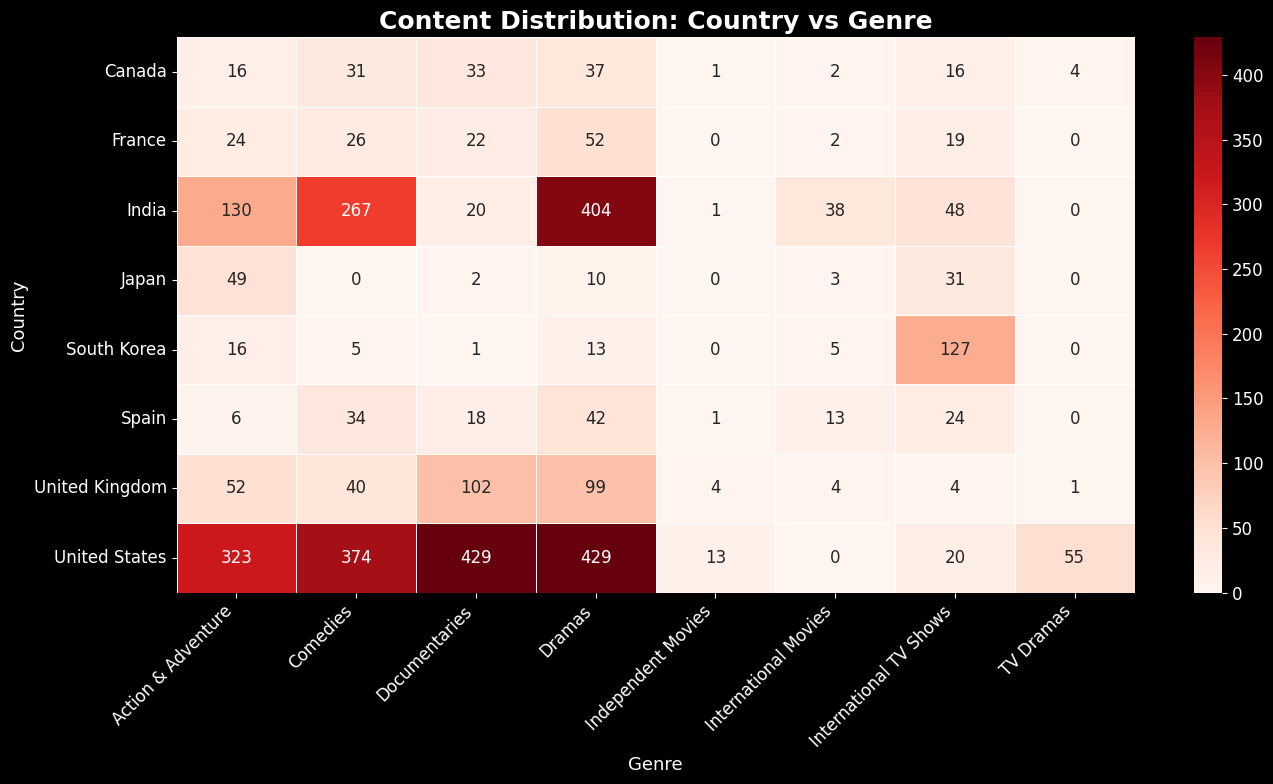

In [81]:
# Country v/s Genre (Heatmap)
top_8_countries=country_df['country_list'].value_counts().head(8).index
top_8_genres=genre_df['genre_list'].value_counts().head(8).index
print(top_8_countries)
print(top_8_genres)

filtered=df[df['primary_country'].isin(top_8_countries)]
filtered=filtered[filtered['primary_genre'].isin(top_8_genres)]

heatmap_data=filtered.groupby(
    ['primary_country','primary_genre']).size().unstack(fill_value=0)

fig,ax=plt.subplots(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='Reds',
    linewidth=0.5,
    ax=ax
)

ax.set_title('Content Distribution: Country vs Genre',
             fontsize=18,fontweight='bold')
ax.set_xlabel('Genre',fontsize=13)
ax.set_ylabel('Country',fontsize=13)
plt.xticks(rotation=45,ha='right')

plt.tight_layout()
plt.savefig('heatmap_country_genre.png',dpi=150, bbox_inches='tight')
plt.show()

# 📊 Netflix Content Analysis — Key Insights & Recommendations

## 🔍 Key Business Insights

### Insight 1: Movies Dominate the Platform
- Netflix has ~70% Movies and ~30% TV Shows
- But TV Show growth rate is increasing faster than Movies after 2019

### Insight 2: Massive Growth After 2015
- Netflix added very little content before 2015
- After 2016, content addition grew rapidly every year
- Peak content addition was in 2019

### Insight 3: USA Dominates Content Production
- USA produces the highest content by far
- India is 2nd highest — shows Netflix's focus on Asian markets
- United Kingdom, Japan, South Korea follow

### Insight 4: International Movies is #1 Genre
- International Movies and Dramas are top genres
- Shows Netflix's global audience strategy
- Comedies and Documentaries are also very popular

### Insight 5: Adult Audience is Primary Target
- TV-MA (Mature Audience) is the most common rating
- Followed by TV-14
- Netflix focuses more on adult content than family/kids content

### Insight 6: Content Addition Peaks in Last Quarter
- October, November, December see highest content additions
- Likely strategy to retain subscribers during holiday season

### Insight 7: India is Fastest Growing Market
- India has rapidly increased content production year over year
- Strong focus on Indian dramas and international movies

---

## 💡 Business Recommendations

### Recommendation 1:
Netflix should invest more in TV Show production
as viewer engagement and watch time is higher for series.

### Recommendation 2:
Expand content production in emerging markets
like South Korea, Nigeria, Brazil
as global audience demand for local content is growing.

### Recommendation 3:
Create more Family and Kids content
as current library is heavily adult-focused
leaving a gap in family audience market.

### Recommendation 4:
Schedule major content launches in Q4
(October-December) to maximize subscriber
retention during holiday season.

### Recommendation 5:
Focus on Documentary genre as it is growing
rapidly and attracts educated, loyal audience.